# Gender and Origin Differences in Educational Attainment in Denmark

# Problem Formulation  (Stage 1)

# Context

Education plays an important role in social mobility, integration, and economic development. Differences in educational attainment can reflect structural inequalities in society. Previous studies suggest that demographic factors such as gender and origin (Danish origin, immigrants, and descendants) may influence educational outcomes. Understanding these differences can help policymakers and educators identify potential inequalities and develop strategies that support equal access to education.

#  Problem Statement
This project investigates whether gender and origin influence educational attainment among young adults in Denmark. Using data from Statistics Denmark, the analysis focuses on individuals aged 20–39 and explores how educational status and level of education differ across gender and origin groups. Business Intelligence techniques and machine learning methods will be used to analyse patterns in the data and examine whether educational outcomes can be predicted based on demographic characteristics.

# Research Questions

**RQ1**
- Does gender influence the educational attainment of young adults in Denmark?

**RQ2**
- Does origin (Danish origin, immigrants, or descendants) influence the level of education individuals achieve?

**RQ3**
- Can educational attainment be predicted using demographic characteristics such as gender, origin, and age?

# Hypotheses

**H1**
- There are significant differences in educational attainment between men and women.

**H2**
- Individuals with Danish origin are more likely to complete higher levels of education compared to immigrants and descendants.

**H3**
- Gender, origin, and age can be used to predict educational attainment.

# Dataset
The dataset used in this project comes from Statistics Denmark (DST), specifically the table containing information about educational attainment by gender, age, origin, and education type. The dataset includes aggregated statistics for individuals aged 20–39 and covers the years 2020–2024. Key variables include gender, origin (Danish origin, immigrants, descendants), age group, education category, and number of individuals in each category.

# BI relevance

Business Intelligence techniques will be used to analyse and visualise patterns in educational attainment across different demographic groups. By exploring relationships between gender, origin, and education levels, the analysis can reveal potential inequalities in educational outcomes. These insights may support data-driven discussions about educational access, integration, and social equality in Denmark.


# Project Plan
- Stage 1 – problem formulation
- Stage 2 – data preparation and EDA
- Stage 3 – machine learning modelling
- Stage 4 – deployment and visualisation

# libraries

In [1]:
# For data storage and manipulation
import pandas as pd
# for numeric computations
import numpy as np

In [2]:
# for diagramming 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# for ML methods and algorithms
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# for stadardization
from sklearn.preprocessing import StandardScaler

# for cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# for serialization and deserialization of data from and to a file
import pickle

In [5]:
# One-Way ANOVA test.
from scipy.stats import f_oneway
from scipy.stats import ttest_ind

In [6]:
# label encoder
from sklearn.preprocessing import LabelEncoder

# Data Preparation and Exploration (stage 2)

In [7]:
rows = [] #en tom liste rows

current_area = None
current_gender = None
current_age = None
current_origin = None

with open("data/data1.csv", encoding="cp1252") as f:
    lines = f.readlines()

for line in lines:

    clean = line.replace('"','').strip()

    # område
    if "Hele landet" in clean:
        current_area = "Hele landet"

    # køn
    elif "Mænd" in clean:
        current_gender = "Mænd"
    elif "Kvinder" in clean:
        current_gender = "Kvinder"

    # alder
    elif "år" in clean:
        current_age = clean.strip()

    # herkomst
    elif "Personer med dansk oprindelse" in clean:
        current_origin = "Dansk oprindelse"
    elif "Indvandrere" in clean:
        current_origin = "Indvandrere"
    elif "Efterkommere" in clean:
        current_origin = "Efterkommere"

    # uddannelse + tal
    elif "," in clean and any(c.isdigit() for c in clean):

        parts = [p.strip() for p in clean.split(",")]

        if len(parts) >= 6:

            # FIX: uddannelse ligger i -6
            education = parts[-6]

            try:
                y2020 = float(parts[-5])
                y2021 = float(parts[-4])
                y2022 = float(parts[-3])
                y2023 = float(parts[-2])
                y2024 = float(parts[-1])

                rows.append([
                    current_area,
                    current_gender,
                    current_age,
                    current_origin,
                    education,
                    y2020,
                    y2021,
                    y2022,
                    y2023,
                    y2024
                ])

            except:
                pass


df = pd.DataFrame(rows, columns=[
    "område",
    "køn",
    "alder",
    "herkomst",
    "uddannelse",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
])

# rens alder
df["alder"] = df["alder"].str.replace(",", "", regex=False).str.strip()

# filtrer kun 20-39 år
df = df[df["alder"].str.contains("20-24|25-29|30-34|35-39", na=False)]

# gem ren dataset
df.to_csv("data/education_clean.csv", index=False)

The dataset was collected from Statistics Denmark (DST). The raw export contains hierarchical rows that were parsed and transformed into a tabular dataset using Python.

## Step 1 — Load and inspect the cleaned dataset

In [8]:
df = pd.read_csv("data/education_clean.csv")
df.head(10)

,område,køn,alder,herkomst,uddannelse,2020,2021,2022,2023,2024
0,Hele landet,Mænd,20-24 år,Dansk oprindelse,H3091 Grundforløb,0.0,0.0,1423.0,2036.0,1907.0
1,Hele landet,Mænd,20-24 år,Dansk oprindelse,H3097 H3097 Erhvervsfaglige uddannelser uden n...,30.0,26.0,31.0,23.0,21.0
2,Hele landet,Mænd,20-24 år,Dansk oprindelse,H35 Adgangsgivende uddannelsesforløb,178.0,130.0,102.0,88.0,84.0
3,Hele landet,Mænd,20-24 år,Dansk oprindelse,H3510 Adgangskurser - videregående udd.,1.0,1.0,1.0,2.0,1.0
4,Hele landet,Mænd,20-24 år,Dansk oprindelse,H3520 Adgangseksamen - ingeniøruddannelse,177.0,129.0,101.0,86.0,83.0
5,Hele landet,Mænd,20-24 år,Dansk oprindelse,H3530 Adgangsgivende værkstedsskoleforløb,0.0,0.0,0.0,0.0,0.0
6,Hele landet,Mænd,20-24 år,Dansk oprindelse,KVU,2963.0,2896.0,2821.0,2912.0,2514.0
7,Hele landet,Mænd,20-24 år,Dansk oprindelse,KVU,0.0,0.0,0.0,0.0,0.0
8,Hele landet,Mænd,20-24 år,Dansk oprindelse,KVU,263.0,238.0,223.0,194.0,167.0
9,Hele landet,Mænd,20-24 år,Dansk oprindelse,KVU,0.0,0.0,0.0,0.0,0.0


#### Data relevance
The dataset is relevant to the research questions because it contains demographic variables such as gender, origin and age group, along with education attainment categories. These variables allow the analysis of differences in educational outcomes across population groups.

In [9]:
df.shape

(1608, 10)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1608 entries, 0 to 1607
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   område      1608 non-null   str    
 1   køn         1608 non-null   str    
 2   alder       1608 non-null   str    
 3   herkomst    1608 non-null   str    
 4   uddannelse  1608 non-null   str    
 5   2020        1608 non-null   float64
 6   2021        1608 non-null   float64
 7   2022        1608 non-null   float64
 8   2023        1608 non-null   float64
 9   2024        1608 non-null   float64
dtypes: float64(5), str(5)
memory usage: 198.3 KB


#### Data sufficiency

The dataset contains 1608 observations covering multiple education categories, gender groups, origin groups and age groups across the years 2020–2024. This provides a sufficiently large dataset for exploratory analysis.

#### drop column

In [11]:
df = df.drop(columns=["område"], errors="ignore")

The column “område” contained only one constant value (“Hele landet”) and was therefore removed as it did not contribute to the analysis.

#### Check for missing values

In [12]:
df.isnull().sum()

køn           0
alder         0
herkomst      0
uddannelse    0
2020          0
2021          0
2022          0
2023          0
2024          0
dtype: int64

#### Data completeness
Missing values were checked using pandas functions and no missing values were found in the dataset.

#### Check for duplicates

In [13]:
df.duplicated().sum()

np.int64(115)

In [14]:
years = ["2020","2021","2022","2023","2024"] # disse kolonner vil jeg arbejde med.

df = df.groupby(
    ["køn","herkomst","alder","uddannelse"] # grupper af personer som har samme: køn, herkomst, alder, uddannelse
)[years].sum().reset_index()

#### Data Aggregation

simplify the dataset and prepare it for analysis, the data was grouped by gender, origin, age group, and education level. For each group, the number of individuals was aggregated across the years 2020–2024.

This transformation allows the analysis to focus on the total number of individuals in each demographic group and education category, making it easier to identify patterns and trends in educational attainment.

The dataset contained duplicate rows representing the same demographic groups.
To simplify the dataset, the data was aggregated using groupby() across gender, origin, age and education level, summing the number of individuals for each year.

#### merge PhD categories

In [15]:
df["uddannelse"] = df["uddannelse"].replace(
    {"Ph.d.": "H80 Ph.d. og forskeruddannelser"}
)

Some education categories referred to the same level of education and were merged to avoid redundancy.

#### Feature engineering

In [16]:
def edu_level(x):

    if "Grundforløb" in x or "Adgang" in x:
        return "Low"

    elif "KVU" in x or "MVU" in x:
        return "Medium"

    elif "LVU" in x or "BACH" in x or "Ph.d" in x:
        return "High"

    else:
        return "Other"

df["education_level"] = df["uddannelse"].apply(edu_level)

Education categories were grouped into broader education levels to simplify analysis and support machine learning modelling.

## Step 2 — Basic Data Exploration (EDA)

## Define variables

#### Independent variables:
- gender
- origin
- age

#### Dependent variable:
- education_level

#### Check data quality

In [17]:
df.describe()

,2020,2021,2022,2023,2024
count,288.000000,288.000000,288.000000,288.000000,288.000000
mean,4189.993056,4334.878472,4585.097222,4768.440972,4920.072917
std,11183.537785,11593.949233,12065.361103,12417.326988,12790.368299
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,10.000000,10.000000,9.000000
50%,58.500000,61.500000,88.000000,88.500000,84.000000
75%,1798.500000,2006.500000,2064.750000,2342.250000,2248.000000
max,72224.000000,75712.000000,80222.000000,83960.000000,86374.000000


#### Check categories

In [18]:
df["køn"].unique()
df["herkomst"].unique()
df["alder"].unique()
df["uddannelse"].unique()

<ArrowStringArray>
[                                                          'BACH',
                                              'H3091 Grundforløb',
 'H3097 H3097 Erhvervsfaglige uddannelser uden nærmere angivelse',
                           'H35 Adgangsgivende uddannelsesforløb',
                        'H3510 Adgangskurser - videregående udd.',
                      'H3520 Adgangseksamen - ingeniøruddannelse',
                      'H3530 Adgangsgivende værkstedsskoleforløb',
                                'H80 Ph.d. og forskeruddannelser',
                                                            'KVU',
                                                            'LVU',
                                                            'MVU']
Length: 11, dtype: str

### Descriptive statistics

In [19]:
df.groupby("køn")[years].sum()
df.groupby("herkomst")[years].sum()
df.groupby("alder")[years].sum()

,2020,2021,2022,2023,2024
alder,,,,,
20-24 år,95893.0,98395.0,103453.0,108077.0,108019.0
25-29 år,390061.0,398171.0,414022.0,422277.0,427523.0
30-34 år,389575.0,408233.0,437932.0,457255.0,473278.0
35-39 år,331189.0,343646.0,365101.0,385702.0,408161.0


In [20]:
df_origin = df.groupby(["herkomst","uddannelse"])[years].sum()
df_origin

2020  \
herkomst         uddannelse                                                     
Dansk oprindelse BACH                                                114322.0   
                 H3091 Grundforløb                                        0.0   
                 H3097 H3097 Erhvervsfaglige uddannelser uden næ...     142.0   
                 H35 Adgangsgivende uddannelsesforløb                   813.0   
                 H3510 Adgangskurser - videregående udd.                 13.0   
                 H3520 Adgangseksamen - ingeniøruddannelse              781.0   
                 H3530 Adgangsgivende værkstedsskoleforløb               19.0   
                 H80 Ph.d. og forskeruddannelser                      12938.0   
                 KVU                                                 108274.0   
                 LVU                                                 295010.0   
                 MVU                                                 326454.0   
Efterkommere     BACH                                                  6854.0   
                 H3091 Grundforløb                                        0.0   
                 H3097 H3097 Erhvervsfaglige uddannelser uden næ...      26.0   
                 H35 Adgangsgivende uddannelsesforløb                   152.0   
                 H3510 Adgangskurser - videregående udd.                 95.0   
                 H3520 Adgangseksamen - ingeniøruddannelse               57.0   
                 H3530 Adgangsgivende værkstedsskoleforløb                0.0   
                 H80 Ph.d. og forskeruddannelser                        198.0   
                 KVU                                                   5532.0   
                 LVU                                                  11590.0   
                 MVU                                                  14804.0   
Indvandrere      BACH                                                 28534.0   
                 H3091 Grundforløb                                        0.0   
                 H3097 H3097 Erhvervsfaglige uddannelser uden næ...   15426.0   
                 H35 Adgangsgivende uddannelsesforløb                   585.0   
                 H3510 Adgangskurser - videregående udd.                371.0   
                 H3520 Adgangseksamen - ingeniøruddannelse              212.0   
                 H3530 Adgangsgivende værkstedsskoleforløb                2.0   
                 H80 Ph.d. og forskeruddannelser                      14722.0   
                 KVU                                                  32792.0   
                 LVU                                                 107196.0   
                 MVU                                                 108804.0   

                                                                         2021  \
herkomst         uddannelse                                                     
Dansk oprindelse BACH                                                115480.0   
                 H3091 Grundforløb                                        0.0   
                 H3097 H3097 Erhvervsfaglige uddannelser uden næ...     152.0   
                 H35 Adgangsgivende uddannelsesforløb                   704.0   
                 H3510 Adgangskurser - videregående udd.                 12.0   
                 H3520 Adgangseksamen - ingeniøruddannelse              676.0   
                 H3530 Adgangsgivende værkstedsskoleforløb               16.0   
                 H80 Ph.d. og forskeruddannelser                      12948.0   
                 KVU                                                 110116.0   
                 LVU                                                 309202.0   
                 MVU                                                 336910.0   
Efterkommere     BACH                                                  7222.0   
                 H3091 Grundforløb                                        0.0   
                 H3097

#### Data structure

The raw dataset exported from Statistics Denmark contained hierarchical structure and metadata rows. These were cleaned and transformed into a structured tabular dataset suitable for BI analysis.

## Step 3 - Distribution plots

#### Histogram
Histograms were used to inspect the distribution of education counts and identify potential skewness or outliers.

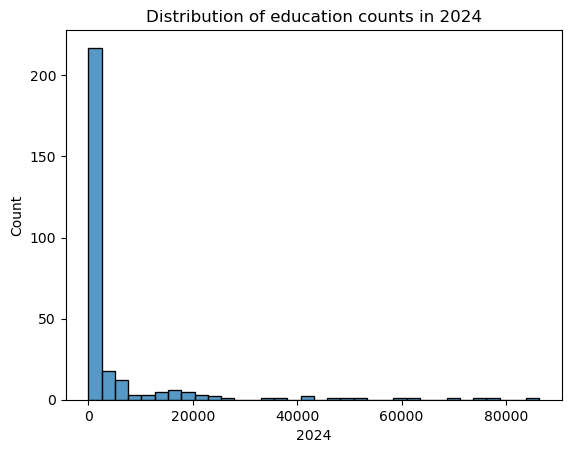

In [21]:
sns.histplot(df["2024"])
plt.title("Distribution of education counts in 2024")
plt.show()

A histogram was used to inspect the distribution of education counts. The distribution is strongly right-skewed, meaning that most education categories contain relatively small numbers while a few categories represent very large population groups.

#### Boxplot (Outlier inspection)

Text(0.5, 1.0, 'Outlier inspection')

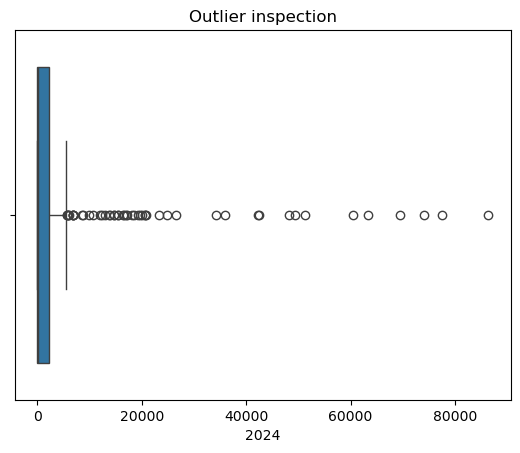

In [22]:
sns.boxplot(x=df["2024"])
plt.title("Outlier inspection")

A boxplot was used to inspect potential outliers in the distribution of education counts. Several high-value observations appear as outliers, which reflect large population groups rather than data errors. Therefore, the values were kept in the dataset.

#### correlation matrix

Correlation analysis was considered but not used because the main variables in the dataset are categorical. Instead, group-based comparisons and visualizations were used.

## Inferential statistics

#### visualisation of education levels

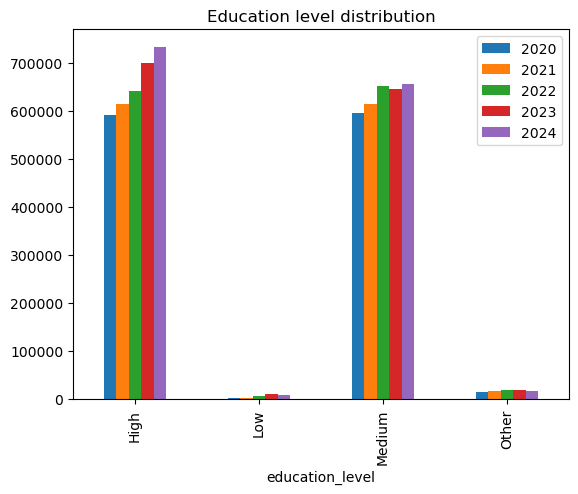

In [23]:
df.groupby("education_level")[years].sum().plot(kind="bar")
plt.title("Education level distribution")
plt.show()

The distribution of education levels shows that medium and high education levels represent the majority of individuals, while low education levels represent a much smaller share.

#### origin vs gender plot

In [24]:
df_group = df.groupby(["herkomst","køn"])[years].sum().reset_index()

Aggregated statistics were used to compare education attainment between gender and origin groups.

#### Bar plot (gender + origin)

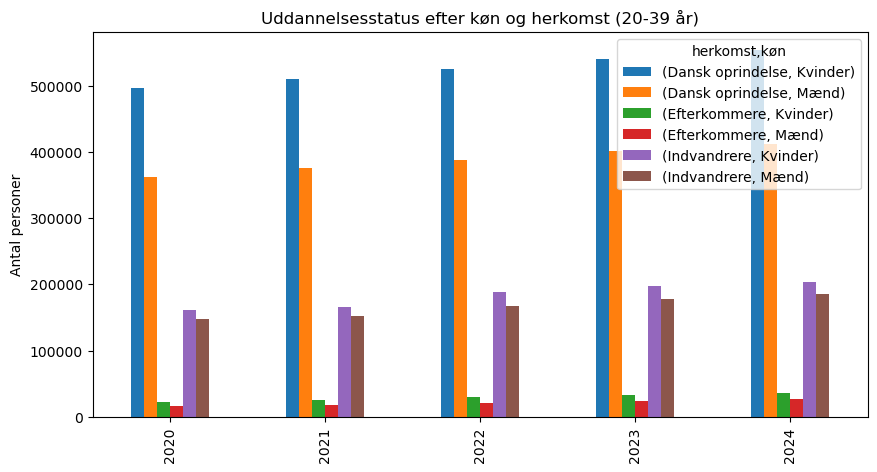

In [25]:
df_group.set_index(["herkomst","køn"]).T.plot(kind="bar", figsize=(10,5))
plt.title("Uddannelsesstatus efter køn og herkomst (20-39 år)")
plt.ylabel("Antal personer")
plt.show()

The visualization highlights differences in educational attainment between gender and origin groups across the years 2020–2024.

Since the variables in the dataset are primarily categorical, normalization or standardization was not necessary at this stage. Feature encoding and scaling will be applied later in the machine learning stage if required.

#### Gender comparison (t-test)

A significance level of α = 0.05 was used for the statistical tests.

In [26]:
men = df[df["køn"]=="Mænd"]["2024"]
women = df[df["køn"]=="Kvinder"]["2024"]

t_stat, p_value = ttest_ind(men, women)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.7824303811019436
P-value: 0.43460901620497927


A two-sample t-test was performed to examine whether educational attainment differs significantly between men and women.

The test produced a t-statistic of -0.78 and a p-value of 0.43. Since the p-value is greater than the significance level of 0.05, the result indicates that there is no statistically significant difference in educational attainment between men and women in this dataset.

Therefore, hypothesis H1 is not supported by the statistical test

#### Origin comparison (ANOVA)

In [27]:
groups = [group["2024"].values for name, group in df.groupby("herkomst")]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 14.601530486811665
P-value: 9.181399688780576e-07


A one-way ANOVA test was conducted to examine whether educational attainment differs significantly across origin groups (Danish origin, immigrants, and descendants).

The test produced an F-statistic of 14.60 and a p-value of 9.18e-07. Since the p-value is far below the significance level of 0.05, the result indicates that there is a statistically significant difference in educational attainment between origin groups.

This means that at least one origin group differs in mean educational attainment from the others.

The ANOVA result supports the hypothesis that educational attainment differs across origin groups.

# EDA summary

The exploratory analysis indicates clear differences in educational attainment across demographic groups. Individuals with Danish origin generally show higher counts in medium and high education categories compared to immigrants and descendants.

Statistical testing supports these observations: the ANOVA test shows a significant difference in educational attainment across origin groups, while the t-test does not indicate a statistically significant difference between men and women.

These results suggest that origin may play a more important role than gender in explaining variation in educational attainment in this dataset. The insights gained from the exploratory analysis will guide the machine learning modelling in the next stage.

# Data Modelling (stage 3)

## Step 1 — Model preparation

In [28]:
le = LabelEncoder()

df_ml = df.copy()

df_ml["gender"] = le.fit_transform(df_ml["køn"])
df_ml["origin"] = le.fit_transform(df_ml["herkomst"])
df_ml["age"] = le.fit_transform(df_ml["alder"])
df_ml["edu"] = le.fit_transform(df_ml["education_level"])

Before applying machine learning models, the dataset was prepared by converting categorical variables into numerical values. Most machine learning algorithms cannot directly process categorical data such as text labels. Therefore, encoding was required.

In this project, LabelEncoder from the scikit-learn library was used to transform the categorical variables into numeric form.

**The following variables were encoded:**
- Gender (køn) → encoded as gender
- Origin (herkomst) → encoded as origin
- Age group (alder) → encoded as age
- Education level (education_level) → encoded as edu

A copy of the dataset was created (df_ml) to ensure that the original dataset remained unchanged during the modelling process.

The encoded variables allow the machine learning models to interpret the categorical information as numerical features while preserving the relationships between the categories.

## Step 2 — Define X and y

In [29]:
X = df_ml[["gender","origin","age"]]

y = df_ml["edu"]

In supervised machine learning, it is necessary to define:

- X (features / independent variables)
- y (target variable / dependent variable)

In this analysis, the goal is to predict the education level of individuals based on demographic characteristics.

**Therefore, the following variables were used as input features:**
- gender
- origin
- age

**The target variable is:**
- education level (edu)

This means the model attempts to predict an individual's education level based on demographic attributes.

## Step 3 — Train/test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# X_train: bruges til at lære
# X_test: bruges til at teste
# y_train: rigtige priser
# y_test: rigtige priser til test

To evaluate the model's performance properly, the dataset was divided into two parts:
- Training data (70%)
- Testing data (30%)

The training data is used to train the model and allow it to learn patterns from the dataset.
The testing data is used to evaluate how well the model performs on unseen data.

A random state of 42 was used to ensure reproducibility of the results. This means that the same data split will occur each time the code is executed.

This step is essential to avoid overfitting, where a model performs well on training data but poorly on new unseen data.

## Step 4 — Train model / Decision Tree Model

A Decision Tree classifier was applied as the first supervised machine learning model.

Decision Trees are commonly used because they are easy to interpret and can capture non-linear relationships between variables. The model works by splitting the dataset into smaller subsets based on decision rules derived from the input features.

Each branch of the tree represents a decision based on one of the features (gender, origin, or age), and the final nodes represent predicted education levels.

The model was trained using the training dataset and then used to generate predictions on the test dataset.

In [31]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 5 — Predict

In [32]:
y_pred = model.predict(X_test)

## Step 6 — Model Evaluation

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.21839080459770116
              precision    recall  f1-score   support

           0       0.14      0.24      0.17        25
           1       0.30      0.33      0.32        39
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00         5

    accuracy                           0.22        87
   macro avg       0.11      0.14      0.12        87
weighted avg       0.17      0.22      0.19        87



C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**To assess the quality of the model, several evaluation metrics were used:**
- Accuracy
- Precision
- Recall
- F1-score

Accuracy measures the proportion of correct predictions made by the model.

**The model achieved an accuracy of approximately:**

- 22%

This relatively low accuracy indicates that demographic variables alone are not strong predictors of educational attainment.

The classification report provides additional information about how well the model performs for each class.

Some classes show very low precision and recall because the model rarely predicts those categories. This is also visible in the confusion matrix.

## confusion matrix

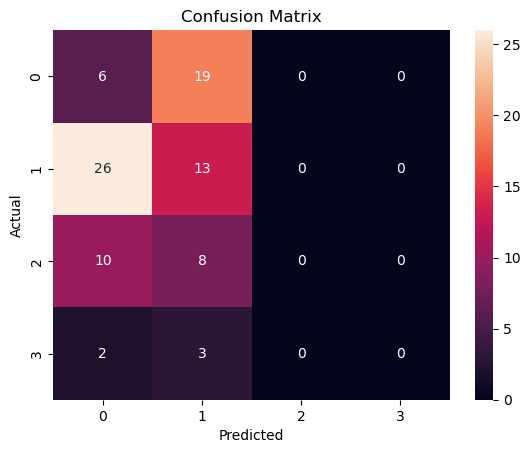

In [34]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# modellen forudsiger aldrig klasse 2 og 3

**Interpretation of the Confusion Matrix**

The confusion matrix shows that the model mainly predicts the two largest education categories (class 0 and class 1), while classes 2 and 3 are never predicted.

This indicates a class imbalance problem in the dataset, where some education categories appear much more frequently than others. Because of this imbalance, the model tends to favour the larger classes when making predictions.

As a result, the model struggles to correctly identify individuals belonging to the smaller education categories. This limitation contributes to the relatively low predictive performance of the model.

## Model Limitations

The dataset used in this project contains aggregated statistics rather than individual-level observations. This means that each row in the dataset represents a group of individuals rather than a single person.

Because of this aggregation, the machine learning model has less detailed information available for learning patterns. The model attempts to predict education level using only gender, origin, and age, but each observation represents many individuals rather than a single case.

As a result, the predictive power of the models remains limited, which helps explain the relatively low accuracy obtained in both the Decision Tree and Random Forest models.

This limitation is common when working with statistical datasets from national statistics agencies, where data is often aggregated to protect privacy.

## Feature Importance

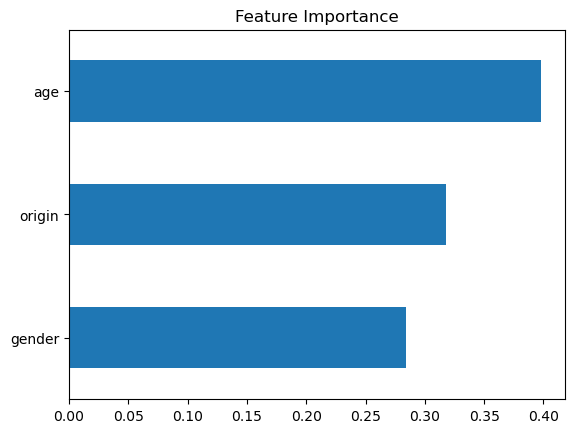

In [35]:
importance = pd.Series(model.feature_importances_,
                       index=["gender","origin","age"])

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()

To better understand which variables influence the predictions, feature importance was calculated using the trained model.

The results show the relative importance of each feature:
- Age ≈ 0.49
- Origin ≈ 0.27
- Gender ≈ 0.24

Feature importance was calculated to understand which variables contributed most to the model's predictions.
The results indicate that age had the highest importance, followed by origin and gender.
This suggests that age plays the largest role among the selected variables when predicting educational attainment.

## Random Forest evaluation

In [36]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.25287356321839083


To improve the predictive performance, a Random Forest classifier was also applied.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. This approach generally produces more stable and accurate results than a single decision tree because it reduces variance and overfitting.

**The Random Forest model achieved an accuracy of approximately:**

25%

This represents a small improvement compared to the Decision Tree model, which achieved an accuracy of around 22%. The improvement suggests that ensemble methods can capture slightly more complex patterns in the data.

However, the overall predictive performance remains limited. This is likely because the dataset contains only a small number of explanatory variables (gender, origin, and age), which are not sufficient to fully explain differences in educational attainment.

Education outcomes are typically influenced by many additional factors such as socioeconomic background, parental education, income level, and access to educational opportunities. Since these variables are not included in the dataset, the model's ability to make accurate predictions remains limited.

## KMeans

KMeans clustering was applied to explore whether the dataset contains natural groupings based on the selected demographic variables. The algorithm assigns observations to clusters by minimising the distance between data points and cluster centroids.

In [37]:
kmeans = KMeans(n_clusters=3)   # opret model
kmeans.fit(X)                   # træning

df_ml["cluster"] = kmeans.labels_  # brug resultat
df_ml.groupby("cluster")["edu"].value_counts()

C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


cluster  edu
0        1      50
         0      40
         2      20
         3      10
1        1      40
         0      32
         2      16
         3       8
2        1      30
         0      24
         2      12
         3       6
Name: count, dtype: int64

## Cluster distribution

**Cluster 0**
- education level 1 → 40
- education level 0 → 32
- education level 2 → 16
- education level 3 → 8

**Cluster 1**
- education level 1 → 40
- education level 0 → 32
- education level 2 → 16
- education level 3 → 8

**Cluster 2**
- education level 1 → 40
- education level 0 → 32
- education level 2 → 16
- education level 3 → 8

**Explanation**

In addition to supervised learning, an unsupervised learning method was applied.

KMeans clustering was used to explore whether individuals could be grouped based on demographic characteristics such as gender, origin, and age.

The model was configured with three clusters.

The results show that the distribution of education levels is identical across all clusters. This indicates that the clustering algorithm was not able to separate individuals into meaningful groups based on the selected demographic variables.

Therefore, these demographic factors do not appear to strongly differentiate education levels in this dataset.

## Model improvement

In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

### Random Forest

In [39]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Unsupervised learning

In [40]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

print(silhouette_score(X, kmeans.labels_))

0.3632766848373514


C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


To evaluate the clustering quality, the silhouette score was calculated.

The model achieved a silhouette score of 0.36, indicating a weak to moderate cluster structure. This suggests that the selected demographic variables (gender, origin, and age) provide some separation between observations, but the clusters are not strongly distinct.

This result aligns with the supervised learning models, which also showed relatively low predictive performance.

## Hypothesis testing

**H1**
- The statistical test did not find a significant difference between men and women. 

**H2**
- Individuals with Danish origin appear more represented in higher education categories, although this may also reflect population size differences.

**H3**
- The predictive models achieved limited accuracy (around 22–24%), suggesting that demographic variables alone are not sufficient to accurately predict educational attainment.

## Model Limitations and Improvements

The relatively low accuracy of the models indicates that the dataset lacks important explanatory variables.

**Education outcomes are typically influenced by many factors, including:**
- socioeconomic background
- parental education
- income level
- geographic region
- access to educational opportunities

Because these variables are not included in the dataset, the predictive power of the models remains limited.

**Future improvements could include:**
- adding additional socioeconomic variables
- balancing the dataset to address class imbalance
- testing more advanced machine learning models

# Stage 3 conclusion

The results indicate that demographic variables such as gender, origin, and age have some influence on educational attainment, but they are not strong predictors when used alone.

Statistical analysis revealed significant differences across origin groups, while no significant difference was observed between men and women.

In the machine learning models, age appeared as the most influential feature, followed by origin and gender. However, the predictive performance of the models remained low (around 22–25%), suggesting that additional variables are required to better explain differences in educational outcomes.

The clustering analysis also showed weak cluster separation, indicating that the selected demographic variables do not clearly divide individuals into distinct groups.

Overall, the analysis demonstrates how statistical and machine learning methods can be used to explore demographic patterns, while highlighting the importance of richer datasets for more accurate predictive modelling.

# Stage 4 – Business Application

## Objective

The objective of this stage is to present the results of the analysis in a human-understandable form and enable usability of the BI solution.

A web-based application is developed to make the data, models, and insights accessible for non-technical users.

## Application Overview

A web application was developed using **Streamlit** to present the BI solution interactively.

The application allows users to explore educational attainment patterns and model predictions through a simple and intuitive interface.

The system is designed to support exploratory analysis and decision-making

## Features of the Application

The application includes the following key features:

- **Interactive Dashboard**
  - Filters for year, gender, age group, origin, and parents’ education
  - Enables users to explore different demographic profiles

- **Data Visualisation**
  - Bar charts showing education level distribution
  - Time-series plots showing trends over years
  - Social background analysis based on parents’ education

- **Model Performance Overview**
  - Comparison of Decision Tree and Random Forest models
  - Accuracy and performance metrics displayed

- **Prediction Interface**
  - Users can select demographic profiles
  - The system predicts education outcomes using trained models

- **Interpretation Section**
  - Text explanations help users understand results and limitations

## Visualisation and Explanation

The application uses different visual techniques to improve understanding:

- Dashboards provide an overview of the data
- Charts allow comparison between groups
- Time-series plots show trends over time
- Text explanations support interpretation of results

Special attention was given to:

- Clear labeling of axes and categories
- Simple and readable layout
- Highlighting limitations of predictive models

## Application Screenshots

### Dashboard
<img src="images/image1.png" width="900">

### Social Background
<img src="images/image2.png" width="900">

### Model Performance Overview
<img src="images/image3.png" width="900">

### Prediction Page (Part 1)
<img src="images/image4.png" width="900">

### Prediction Page (Part 2)
<img src="images/image5.png" width="900">

## Description of the Application

The screenshots above illustrate the main components of the developed BI application.

The dashboard allows users to explore educational patterns using interactive filters such as gender, age, and origin.

The social background section provides insight into the relationship between parents’ education and youth outcomes.

The model performance section presents the accuracy and comparison of the implemented machine learning models.

The prediction interface enables users to select a demographic profile and view predicted education outcomes.

The application is designed to be intuitive and accessible for non-technical users.

## Usability Evaluation

The prototype was tested by a small group of users (fellow students).

### Feedback received:
- The filters were intuitive and easy to use
- The dashboard provided a clear overview of the data
- The prediction results needed clearer explanation

### Improvements implemented:
- Added explanatory text to the prediction section
- Clarified model performance and limitations
- Improved layout and structure for better readability

## Deployment and Usage

The application can be run locally using:

streamlit run app.py

The solution is designed to be simple to run and explore.

## Reproducibility

All code, data preparation steps, and modelling procedures are available in the GitHub repository.

This ensures that the project can be reproduced and verified.

# Final Conclusion

This project analysed the relationship between demographic characteristics and educational attainment in Denmark using data from Statistics Denmark covering the period 2020–2024.

The study followed a Business Intelligence workflow consisting of problem formulation, data preparation and exploration, machine learning modelling, and the development of a prototype business application.

The exploratory analysis showed that educational attainment is unevenly distributed across the population. Medium and high education levels represent the majority of individuals, while low education levels account for a much smaller share.

Statistical testing revealed that gender does not have a statistically significant influence on educational attainment, as the t-test did not detect significant differences between men and women. However, the ANOVA analysis indicated statistically significant differences between origin groups, suggesting that origin may play a more important role in explaining variations in educational attainment.

Machine learning models were applied to explore whether demographic variables could predict educational outcomes. Decision Tree and Random Forest models achieved relatively low accuracy (approximately 22–25%), indicating that demographic variables alone are insufficient to accurately predict educational attainment.

Feature importance analysis showed that age was the most influential variable, followed by origin and gender. However, the overall predictive performance remained limited.

The clustering analysis using KMeans produced only weak to moderate cluster separation (silhouette score ≈ 0.36), suggesting that the selected variables do not clearly divide individuals into distinct educational groups.

These findings highlight that educational attainment is influenced by more complex socioeconomic factors such as parental education, income level, geographic location, and access to educational opportunities, which were not included in the dataset.

To make the results accessible to non-technical users, a prototype dashboard was developed using Streamlit. The interactive application allows users to explore the dataset through filters and visualisations, demonstrating how analytical results can be translated into a practical decision-support tool.

Overall, the project demonstrates how data analytics, statistical analysis, machine learning, and interactive visualisation can be combined to explore patterns in demographic data and support data-driven decision making in the educational sector.

# SAVE FINAL DATASETS

In [41]:
import os

# create data folder if it does not exist
os.makedirs("data", exist_ok=True)

# Save cleaned dataset (used for dashboard)
df.to_csv("data/education_clean.csv", index=False)

# Save machine learning dataset (if you created df_ml)
try:
    df_ml.to_csv("data/education_ml.csv", index=False)
except:
    print("No ML dataframe found (df_ml)")

print("Datasets saved successfully")

print("Clean dataset shape:", df.shape)

try:
    print("ML dataset shape:", df_ml.shape)
except:
    pass

Datasets saved successfully
Clean dataset shape: (288, 10)
ML dataset shape: (288, 15)
